In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

pd.options.display.float_format = '{:.3f}'.format

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [ ]:
df= pd.read_csv("../clean_data/filtered_icfes_data.csv")
df.head()


,periodo,estu_consecutivo,cole_area_ubicacion,cole_calendario,cole_cod_dane_sede,cole_jornada,cole_naturaleza,cole_nombre_sede,fami_educacionmadre,fami_educacionpadre,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224,SB11202240152772,RURAL,A,320013000000.000,MAÑANA,OFICIAL,INSTITUCION EDUCATIVA DIVINO NIÑO,Primaria completa,Primaria completa,A-,35.000,38.000,37.000,36.000,36.000,183.000
1,20224,SB11202240042820,RURAL,A,220614000000.000,MAÑANA,OFICIAL,INSTITUCION EDUCATIVA AGROPECUARIA LOS ANGELES,Primaria completa,Primaria completa,A-,45.000,46.000,47.000,43.000,52.000,234.000
2,20224,SB11202240462114,URBANO,A,120400000000.000,MAÑANA,OFICIAL,INSTITUCION EDUCATIVA LUIS CARLOS GALAN SARMIENTO,Primaria incompleta,Primaria completa,A1,54.000,37.000,31.000,42.000,41.000,195.000
3,20224,SB11202240377474,RURAL,A,420013000000.000,MAÑANA,NO OFICIAL,FUNDACION EDUCATIVA NUESTRA SEÑORA DE LAS FLORES,Educación profesional completa,Educación profesional completa,A1,57.000,53.000,61.000,54.000,58.000,283.000
4,20224,SB11202240444419,URBANO,A,120238000000.000,NOCHE,OFICIAL,INSTITUCION EDUCATIVA INSTITUTO AGRICOLA,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) completa,A-,31.000,33.000,39.000,41.000,35.000,183.000


In [3]:
# Contar NAs
nas= df.isna().any(axis=1).sum()
print(nas)

50285


In [4]:
print(f'Dimensiones: {df.shape}')
print(f'\nVariables: {list(df.columns)}')

Dimensiones: (125185, 17)

Variables: ['periodo', 'estu_consecutivo', 'cole_area_ubicacion', 'cole_calendario', 'cole_cod_dane_sede', 'cole_jornada', 'cole_naturaleza', 'cole_nombre_sede', 'fami_educacionmadre', 'fami_educacionpadre', 'desemp_ingles', 'punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas', 'punt_c_naturales', 'punt_lectura_critica', 'punt_global']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125185 entries, 0 to 125184
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   periodo                   125185 non-null  int64  
 1   estu_consecutivo          125185 non-null  object 
 2   cole_area_ubicacion       125185 non-null  object 
 3   cole_calendario           125185 non-null  object 
 4   cole_cod_dane_sede        125185 non-null  float64
 5   cole_jornada              125185 non-null  object 
 6   cole_naturaleza           125185 non-null  object 
 7   cole_nombre_sede          125185 non-null  object 
 8   fami_educacionmadre       122198 non-null  object 
 9   fami_educacionpadre       122234 non-null  object 
 10  desemp_ingles             125115 non-null  object 
 11  punt_ingles               125118 non-null  float64
 12  punt_matematicas          125185 non-null  float64
 13  punt_sociales_ciudadanas  77575 non-null   f

In [6]:
# 3.1 Verificar valores faltantes
print('Valores faltantes por variable:')
print(df.isnull().sum())
print(f'\nTotal de valores faltantes: {df.isnull().sum().sum()}')

Valores faltantes por variable:
periodo                         0
estu_consecutivo                0
cole_area_ubicacion             0
cole_calendario                 0
cole_cod_dane_sede              0
cole_jornada                    0
cole_naturaleza                 0
cole_nombre_sede                0
fami_educacionmadre          2987
fami_educacionpadre          2951
desemp_ingles                  70
punt_ingles                    67
punt_matematicas                0
punt_sociales_ciudadanas    47610
punt_c_naturales            47610
punt_lectura_critica        47610
punt_global                 47610
dtype: int64

Total de valores faltantes: 196515


In [7]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
periodo,125185.000,20153.505,36.592,20101.000,20122.000,20152.000,20172.000,20224.000
cole_cod_dane_sede,125185.000,179302919575.029,85900906917.836,120001000000.000,120002000000.000,120295000000.000,220250000000.000,420710000000.000
punt_ingles,125118.000,46.243,10.485,-1.000,40.000,44.930,51.000,117.290
punt_matematicas,125185.000,47.180,11.010,0.000,40.000,46.000,54.000,116.000
punt_sociales_ciudadanas,77575.000,47.117,10.933,0.000,39.000,47.000,55.000,100.000
punt_c_naturales,77575.000,48.708,9.892,0.000,42.000,48.000,55.000,100.000
punt_lectura_critica,77575.000,50.091,9.789,0.000,43.000,50.000,57.000,100.000
punt_global,77575.000,242.931,45.876,0.000,209.000,238.000,272.000,465.000


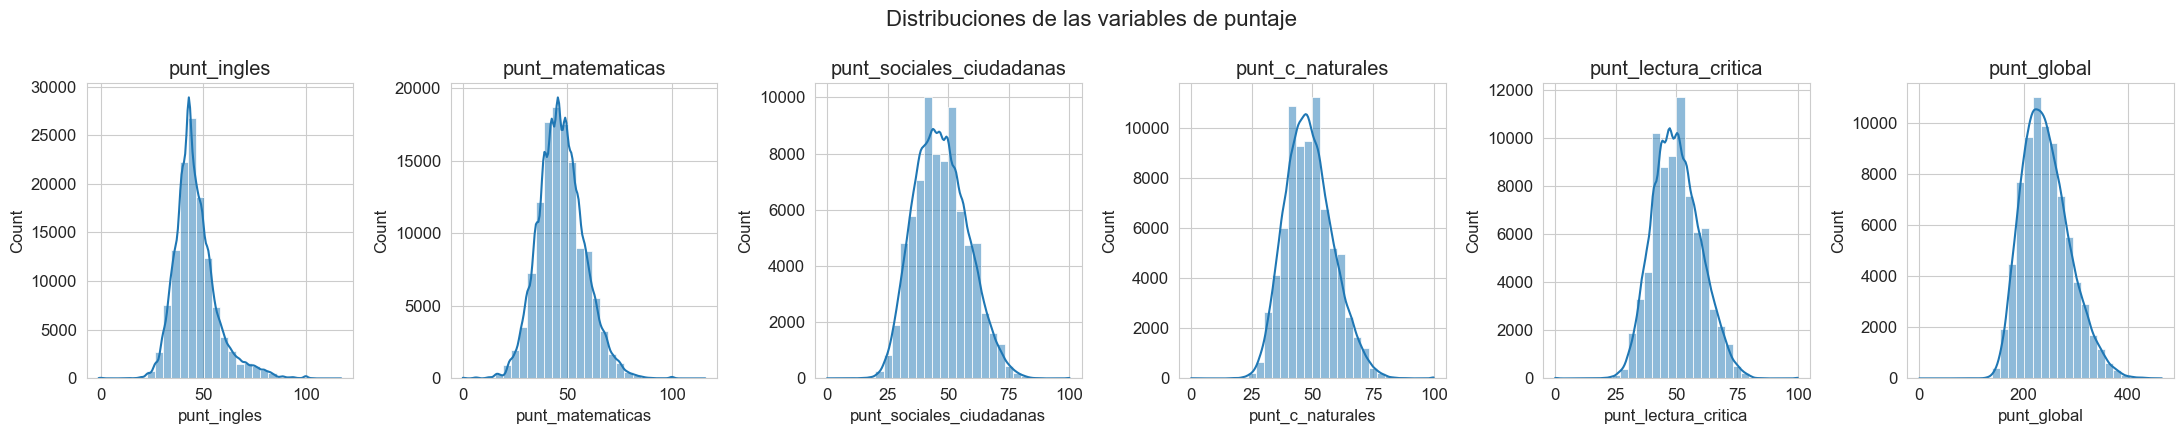

In [8]:
punt_cols = ['punt_ingles','punt_matematicas','punt_sociales_ciudadanas','punt_c_naturales','punt_lectura_critica','punt_global']

plt.figure(figsize=(22, 4))
for i, col in enumerate(punt_cols):
    plt.subplot(1, len(punt_cols), i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.suptitle('Distribuciones de las variables de puntaje', y=1.08, fontsize=16)
plt.show()

In [9]:
# Puntajes individuales
areas = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica"]

for col in areas:
    invalidos = df[(df[col] < 0) | (df[col] > 100)]
    print(f"\nValores inválidos en {col}: {len(invalidos)}")

# Puntaje global
invalidos_global = df[(df["punt_global"] < 0) | (df["punt_global"] > 500)]
print(f"\nValores inválidos en punt_global: {len(invalidos_global)}")


Valores inválidos en punt_ingles: 20

Valores inválidos en punt_matematicas: 6

Valores inválidos en punt_sociales_ciudadanas: 0

Valores inválidos en punt_c_naturales: 0

Valores inválidos en punt_lectura_critica: 0

Valores inválidos en punt_global: 0


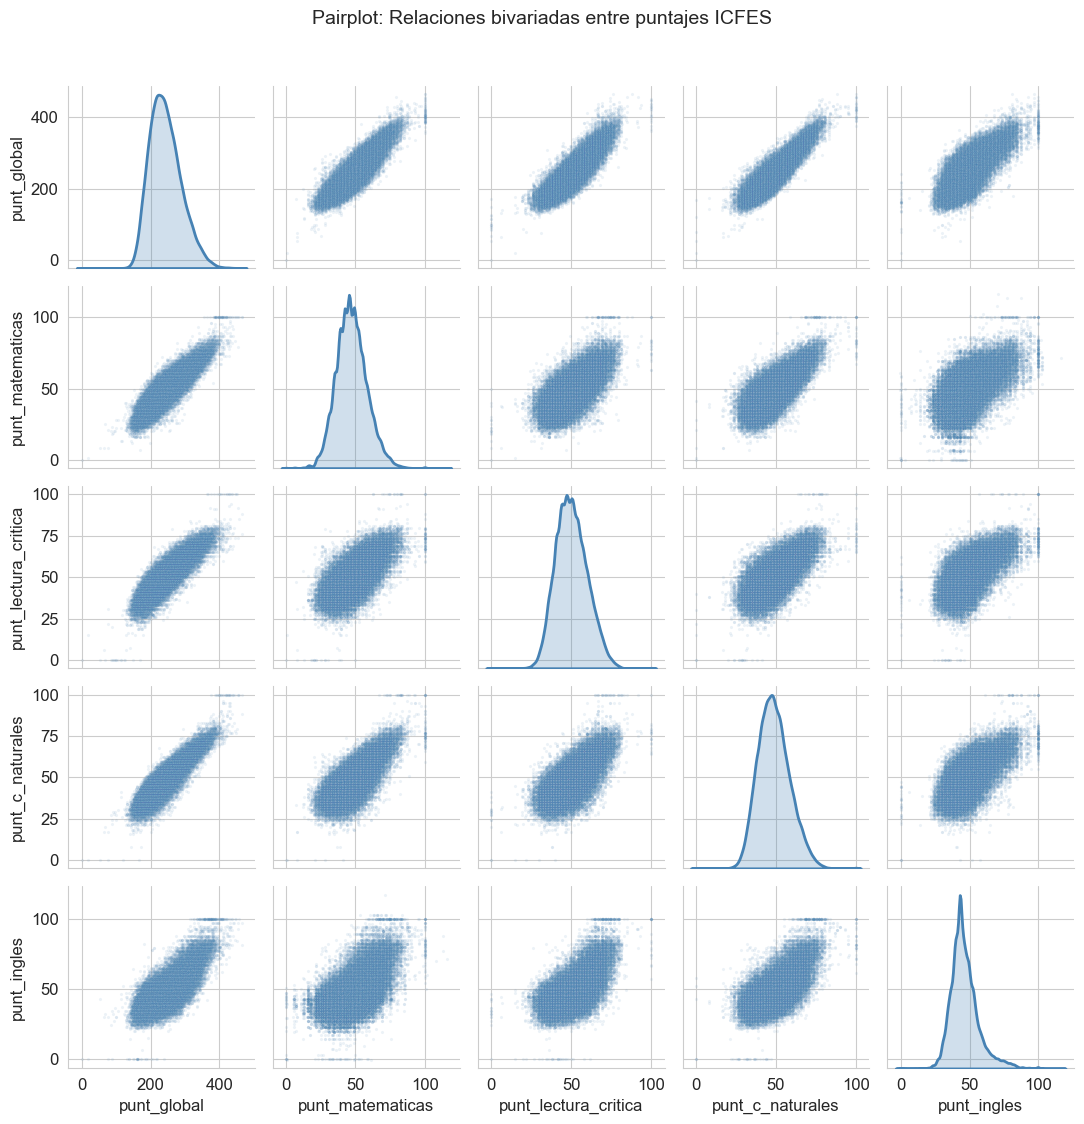

In [10]:
vars_pairplot = ["punt_global","punt_matematicas","punt_lectura_critica","punt_c_naturales","punt_ingles"]
g = sns.pairplot(df[vars_pairplot], diag_kind="kde", plot_kws={"alpha": 0.1, "s": 5, "color": "steelblue"}, diag_kws={"color": "steelblue", "linewidth": 2}, height=2.2, aspect=1)
g.figure.suptitle("Pairplot: Relaciones bivariadas entre puntajes ICFES", fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

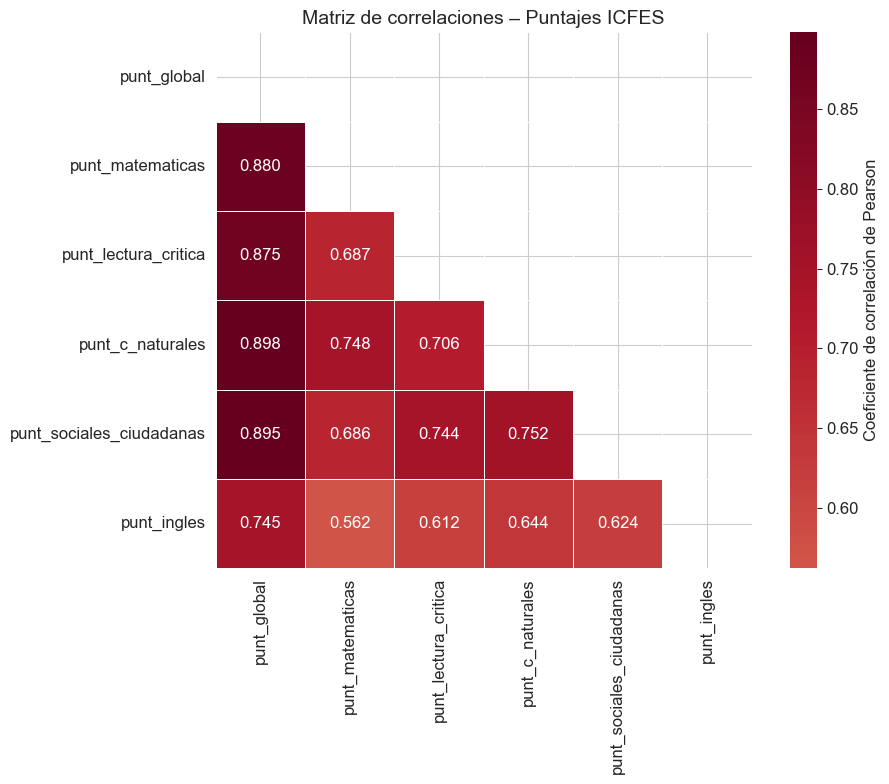

In [11]:
#Correlaciones
vars_corr = ["punt_global", "punt_matematicas", "punt_lectura_critica", "punt_c_naturales", "punt_sociales_ciudadanas","punt_ingles"]

# Calculamos matriz de correlación (Pearson recomendado aquí)
corr_matrix = df[vars_corr].corr(method="pearson")

# Graficamos
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r", center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={"label":"Coeficiente de correlación de Pearson"})
ax.set_title("Matriz de correlaciones – Puntajes ICFES", fontsize=14)

plt.tight_layout()
plt.show()

cole_area_ubicacion
URBANO    106479
RURAL      18706
Name: count, dtype: int64


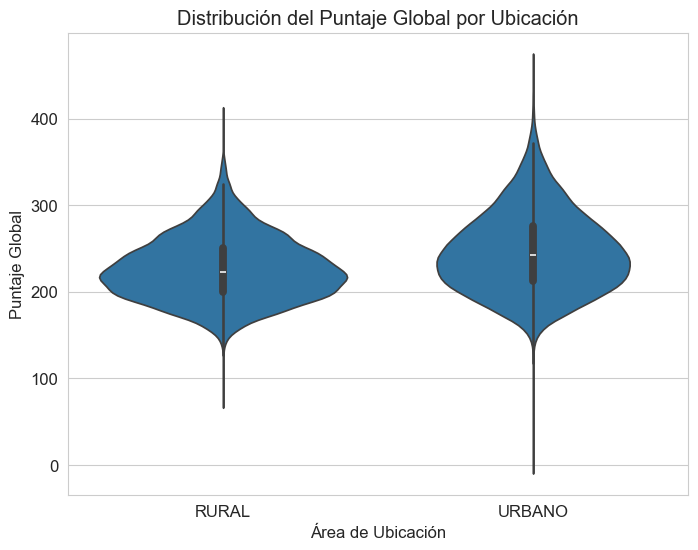

In [12]:
#Boxplots por categorías
ubi= df["cole_area_ubicacion"].value_counts()
print(ubi)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_area_ubicacion", y="punt_global", inner="box")

plt.title("Distribución del Puntaje Global por Ubicación")
plt.xlabel("Área de Ubicación")
plt.ylabel("Puntaje Global")
plt.show()

In [13]:
urbano = df[df["cole_area_ubicacion"] == "URBANO"]["punt_global"]
rural = df[df["cole_area_ubicacion"] == "RURAL"]["punt_global"]

mean1 = urbano.mean()
mean2 = rural.mean()
print("Media grupo 1:", mean1)
print("Media grupo 2:", mean2)
print("Diferencia:", mean1 - mean2)

t_stat, p_value = stats.ttest_ind(urbano, rural, equal_var=True)

print("t-statistic:", t_stat)
print("p-value:", p_value)

Media grupo 1: 246.02163240257747
Media grupo 2: 226.6771278741428
Diferencia: 19.34450452843467
t-statistic: nan
p-value: nan


cole_calendario
A    124589
B       596
Name: count, dtype: int64


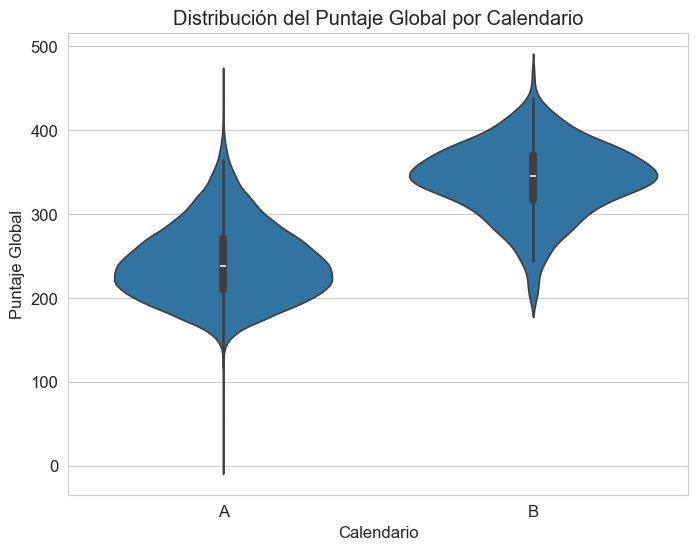

In [14]:
calend= df["cole_calendario"].value_counts()
print(calend)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_calendario", y="punt_global",inner="box")

plt.title("Distribución del Puntaje Global por Calendario")
plt.xlabel("Calendario")
plt.ylabel("Puntaje Global")
plt.show()

In [15]:
A = df[df["cole_calendario"] == "A"]["punt_global"]
B = df[df["cole_calendario"] == "B"]["punt_global"]

mean1 = A.mean()
mean2 = B.mean()
print("Media grupo 1:", mean1)
print("Media grupo 2:", mean2)
print("Diferencia:", mean1 - mean2)

t_stat, p_value = stats.ttest_ind(A, B, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

Media grupo 1: 242.45626465292798
Media grupo 2: 341.4032258064516
Diferencia: -98.9469611535236
t-statistic: nan
p-value: nan


In [32]:
#Contar cruzado calendario y tipo oficial o no
pd.crosstab(df["cole_calendario"], df["cole_naturaleza"], normalize="index")*100

cole_naturaleza,NO OFICIAL,OFICIAL
cole_calendario,,
A,17.252,82.748
B,100.000,0.000


cole_jornada
MAÑANA      67127
TARDE       26018
COMPLETA    12110
NOCHE        7984
SABATINA     6092
UNICA        5854
Name: count, dtype: int64


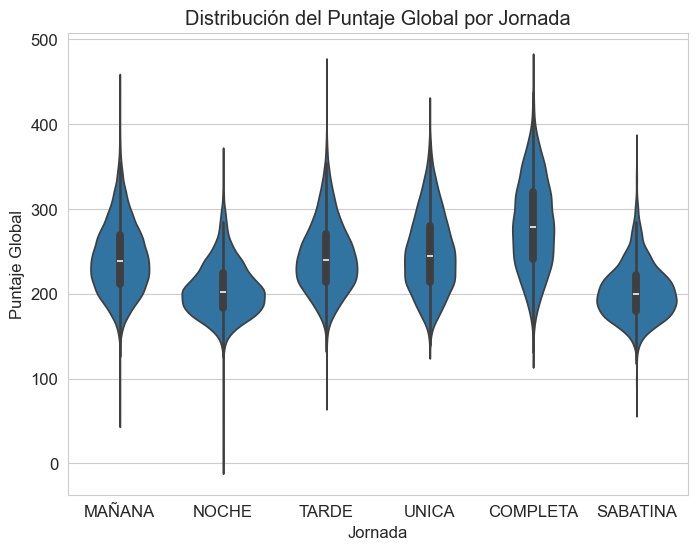

In [17]:
jorn= df["cole_jornada"].value_counts()
print(jorn)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_jornada", y="punt_global",inner="box")

plt.title("Distribución del Puntaje Global por Jornada")
plt.xlabel("Jornada")
plt.ylabel("Puntaje Global")
plt.show()


cole_naturaleza
OFICIAL       103095
NO OFICIAL     22090
Name: count, dtype: int64


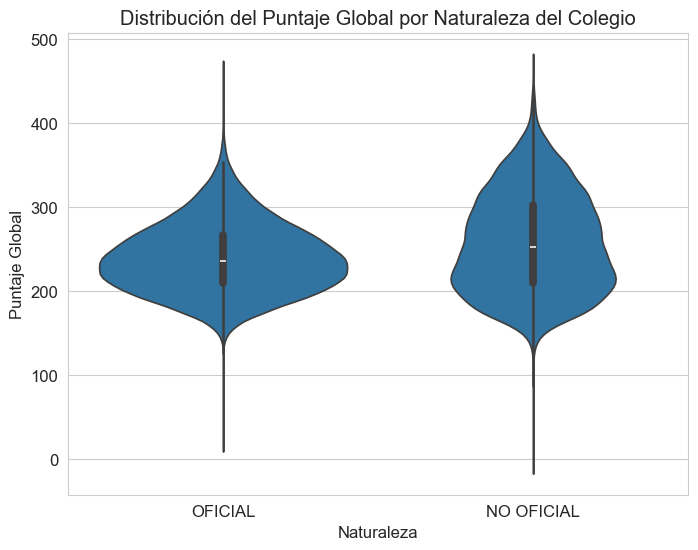

In [18]:
pub= df["cole_naturaleza"].value_counts()
print(pub)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_naturaleza", y="punt_global",inner="box")

plt.title("Distribución del Puntaje Global por Naturaleza del Colegio")
plt.xlabel("Naturaleza")
plt.ylabel("Puntaje Global")
plt.show()

In [19]:
publico = df[df["cole_naturaleza"] == "OFICIAL"]["punt_global"]
privado = df[df["cole_naturaleza"] == "NO OFICIAL"]["punt_global"]

t_stat, p_value = stats.ttest_ind(publico, privado, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: nan
p-value: nan


In [20]:
pub= df["fami_educacionmadre"].value_counts()
print(pub)
print("-----------")
pub= df["fami_educacionpadre"].value_counts()
print(pub)


fami_educacionmadre
Secundaria (Bachillerato) completa      33134
Primaria incompleta                     18377
Secundaria (Bachillerato) incompleta    17980
Primaria completa                       16993
Educación profesional completa          12129
Técnica o tecnológica completa          10298
Ninguno                                  4346
Técnica o tecnológica incompleta         2739
No sabe                                  2343
Educación profesional incompleta         2048
Postgrado                                1735
No Aplica                                  76
Name: count, dtype: int64
-----------
fami_educacionpadre
Secundaria (Bachillerato) completa      30625
Primaria incompleta                     21436
Primaria completa                       17060
Secundaria (Bachillerato) incompleta    16188
Educación profesional completa          11655
Técnica o tecnológica completa           7411
Ninguno                                  7041
No sabe                                  4807
Té

<Figure size 1200x700 with 0 Axes>

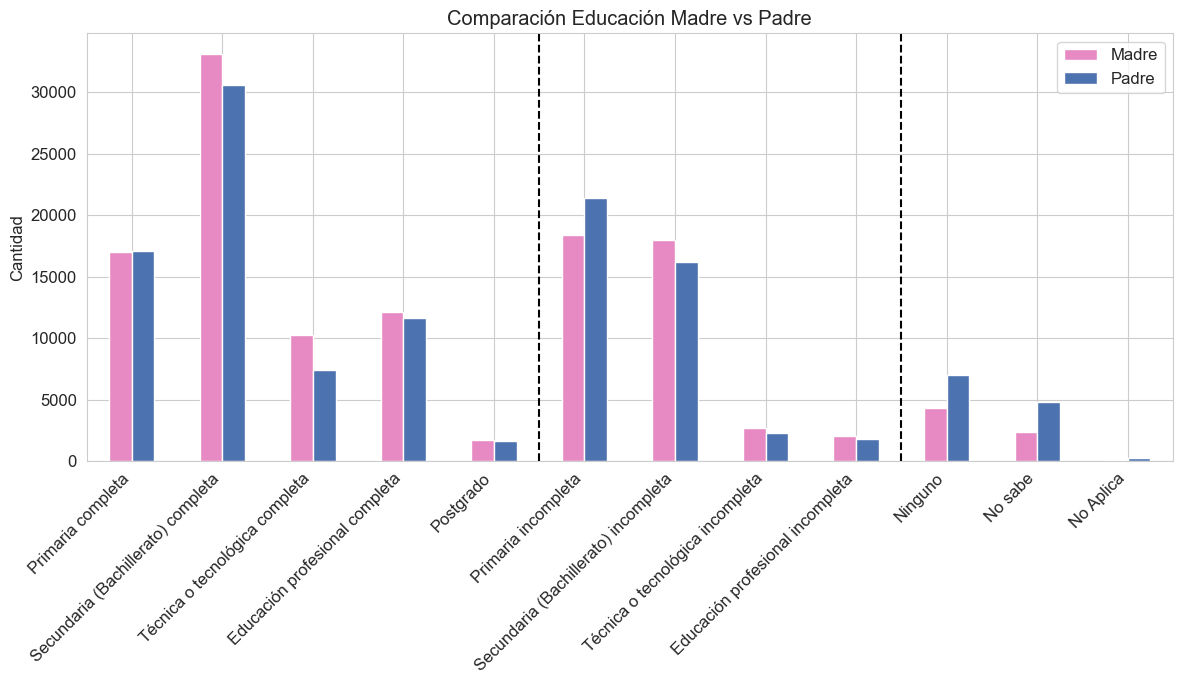

In [21]:
madre_counts = df["fami_educacionmadre"].value_counts()
padre_counts = df["fami_educacionpadre"].value_counts()

tabla = pd.DataFrame({
    "Madre": madre_counts,
    "Padre": padre_counts
}).fillna(0)

orden = ["Primaria completa", "Secundaria (Bachillerato) completa", "Técnica o tecnológica completa", "Educación profesional completa", "Postgrado",
                       
    "Primaria incompleta", "Secundaria (Bachillerato) incompleta", "Técnica o tecnológica incompleta", "Educación profesional incompleta",

    "Ninguno", "No sabe", "No Aplica"]
tabla = tabla.reindex(orden)

plt.figure(figsize=(12,7))
ax = tabla.plot(kind="bar", figsize=(12,7), color=["#E78AC3", "#4C72B0"])
plt.title("Comparación Educación Madre vs Padre")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.axvline(x=4.5, color='black', linestyle='--')
plt.axvline(x=8.5, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
#modelo RL
#punt_global= \beta_0 + \gamma_1*cole_naturaleza[oficial] + \gamma_2*cole_calendario[A] + \gamma_3*cole_area_ubicacion[RURAL] + \gamma_4*cole_jornada[MAÑANA]
#                     + \gamma_5*fami_educacion_madre[Educación profesional completa] + \gamma_6*fami_educacion_padre[Educación profesional completa] + \epsilon

modelo = smf.ols("""punt_global ~ C(cole_naturaleza, Treatment(reference="OFICIAL")) + C(cole_calendario, Treatment(reference="A")) +
C(cole_area_ubicacion, Treatment(reference="URBANO")) + C(cole_jornada, Treatment(reference="MAÑANA")) +
C(fami_educacionmadre, Treatment(reference="Secundaria (Bachillerato) completa")) + 
C(fami_educacionpadre, Treatment(reference="Secundaria (Bachillerato) completa"))
""", data=df).fit(cov_type="HC3")




In [ ]:
sm.stats.anova_lm(modelo, typ=2)

,df,sum_sq,mean_sq,F,PR(>F)
"C(cole_naturaleza, Treatment(reference=""OFICIAL""))",1.000,3787477.620,3787477.620,2386.042,0.000
"C(cole_calendario, Treatment(reference=""A""))",1.000,2548121.791,2548121.791,1605.270,0.000
"C(cole_area_ubicacion, Treatment(reference=""URBANO""))",1.000,2501189.023,2501189.023,1575.703,0.000
"C(cole_jornada, Treatment(reference=""MAÑANA""))",5.000,20953885.408,4190777.082,2640.113,0.000
"C(fami_educacionmadre, Treatment(reference=""Secundaria (Bachillerato) completa""))",11.000,6385990.091,580544.554,365.732,0.000
"C(fami_educacionpadre, Treatment(reference=""Secundaria (Bachillerato) completa""))",11.000,1542461.577,140223.780,88.338,0.000
Residual,74933.000,118944727.775,1587.348,NaN,NaN


In [30]:
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            punt_global   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     811.4
Date:                Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:49:12   Log-Likelihood:            -3.8259e+05
No. Observations:               74964   AIC:                         7.652e+05
Df Residuals:                   74933   BIC:                         7.655e+05
Df Model:                          30                                         
Covariance Type:                  HC3                                         
=============================================================================================================================================================================================
                                                                                                                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                                   245.0602      0.376    651.305      0.000     244.323     245.798
C(cole_naturaleza, Treatment(reference="OFICIAL"))[T.NO OFICIAL]                                                              9.5907      0.608     15.785      0.000       8.400      10.782
C(cole_calendario, Treatment(reference="A"))[T.B]                                                                            41.2352      2.385     17.286      0.000      36.560      45.910
C(cole_area_ubicacion, Treatment(reference="URBANO"))[T.RURAL]                                                              -13.2907      0.400    -33.261      0.000     -14.074     -12.508
C(cole_jornada, Treatment(reference="MAÑANA"))[T.COMPLETA]                                                                   16.0152      0.684     23.403      0.000      14.674      17.356
C(cole_jornada, Treatment(reference="MAÑANA"))[T.NOCHE]                                                                     -34.7549      0.567    -61.270      0.000     -35.867     -33.643
C(cole_jornada, Treatment(reference="MAÑANA"))[T.SABATINA]                                                                  -46.7894      0.809    -57.870      0.000     -48.374     -45.205
C(cole_jornada, Treatment(reference="MAÑANA"))[T.TARDE]                                                                      -0.1148      0.400     -0.287      0.774      -0.898       0.669
C(cole_jornada, Treatment(reference="MAÑANA"))[T.UNICA]                                                                       4.8321      0.621      7.785      0.000       3.616       6.049
C(fami_educacionmadre, Treatment(reference="Secundaria (Bachillerato) completa"))[T.Educación profesional completa]          13.0412      0.666     19.577      0.000      11.736      14.347
C(fami_educacionmadre, Treatment(reference="Secundaria (Bachillerato) completa"))[T.Educación profesional incompleta]        13.5635      1.280     10.595      0.000      11.054      16.073
C(fami_educacionmadre, Treatment(reference="Secundaria (Bachillerato) completa"))[T.Ninguno]                                 -8.8558      0.847    -10.454      0.000     -10.516      -7.196
C(fami_educacionmadre, Treatment(reference="Secundaria (Bachillerato) completa"))[T.No Aplica]                              -27.3710      4.457     -6.141      0.000     -36.106     -18.635
C(fami_educacionmadre, Treatment(reference=

In [ ]:
#pasarlo a tabla
coef = pd.DataFrame({
    "coef": modelo.params,
    "se": modelo.bse,
    "z": modelo.tvalues,
    "p": modelo.pvalues,
    "ci_low": modelo.conf_int()[0],
    "ci_high": modelo.conf_int()[1],
})
coef = coef.sort_values("p")
print(coef)

                                                      coef    se       z  \
Intercept                                          245.060 0.376 651.305   
C(cole_jornada, Treatment(reference="MAÑANA"))[... -34.755 0.567 -61.270   
C(cole_jornada, Treatment(reference="MAÑANA"))[... -46.789 0.809 -57.870   
C(cole_area_ubicacion, Treatment(reference="URB... -13.291 0.400 -33.261   
C(cole_jornada, Treatment(reference="MAÑANA"))[...  16.015 0.684  23.403   
C(fami_educacionmadre, Treatment(reference="Sec...  13.041 0.666  19.577   
C(cole_calendario, Treatment(reference="A"))[T.B]   41.235 2.385  17.286   
C(fami_educacionmadre, Treatment(reference="Sec...  26.736 1.642  16.281   
C(cole_naturaleza, Treatment(reference="OFICIAL...   9.591 0.608  15.785   
C(fami_educacionmadre, Treatment(reference="Sec...   9.124 0.580  15.720   
C(fami_educacionpadre, Treatment(reference="Sec...  24.518 1.690  14.509   
C(fami_educacionpadre, Treatment(reference="Sec...   9.626 0.684  14.072   
C(fami_educa